In [2]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [3]:
pd.set_option('display.max_columns', None)
df_eval = pd.read_csv("data/extrait_eval.csv")
df_eval["id_employee"] = df_eval['eval_number'].str.replace('E_', '')
df_eval.drop('eval_number', axis=1, inplace=True)
df_eval.head()


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,id_employee
0,2,3,2,4,1,1,3,Oui,11 %,1
1,3,2,2,2,4,3,4,Non,23 %,2
2,4,2,1,3,2,3,3,Oui,15 %,4
3,4,3,1,3,3,3,3,Oui,11 %,5
4,1,3,1,2,4,3,3,Non,12 %,7


In [4]:
df_sirh = pd.read_csv("data/extrait_sirh.csv")
df_sirh["id_employee"] = df_sirh["id_employee"].astype(str)
df_sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


In [5]:
df_merge_temp = df_sirh.merge(df_eval, how = "inner", on = ["id_employee"])
df_merge_temp.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %


In [6]:
df_sondage = pd.read_csv("data/extrait_sondage.csv")
df_sondage['id_employee'] = df_sondage['code_sondage'].astype(str)
df_sondage.drop('code_sondage', axis=1, inplace=True)
df_sondage.head()
#print(str(df_sondage['code_sondage']))

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,id_employee
0,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1
1,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7,2
2,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0,4
3,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0,5
4,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2,7


In [7]:
df_merge = df_merge_temp.merge(df_sondage, how = "inner", on = ["id_employee"])

In [8]:
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,Oui,11 %,Oui,0,0,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,Non,23 %,Non,1,3,1,8,1,Infra & Cloud,Y,Frequent,1,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,Oui,15 %,Oui,0,3,1,2,2,Autre,Y,Occasionnel,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,Oui,11 %,Non,0,3,1,3,4,Infra & Cloud,Y,Frequent,3,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,Non,12 %,Non,1,3,1,2,1,Transformation Digitale,Y,Occasionnel,2,2


<Axes: >

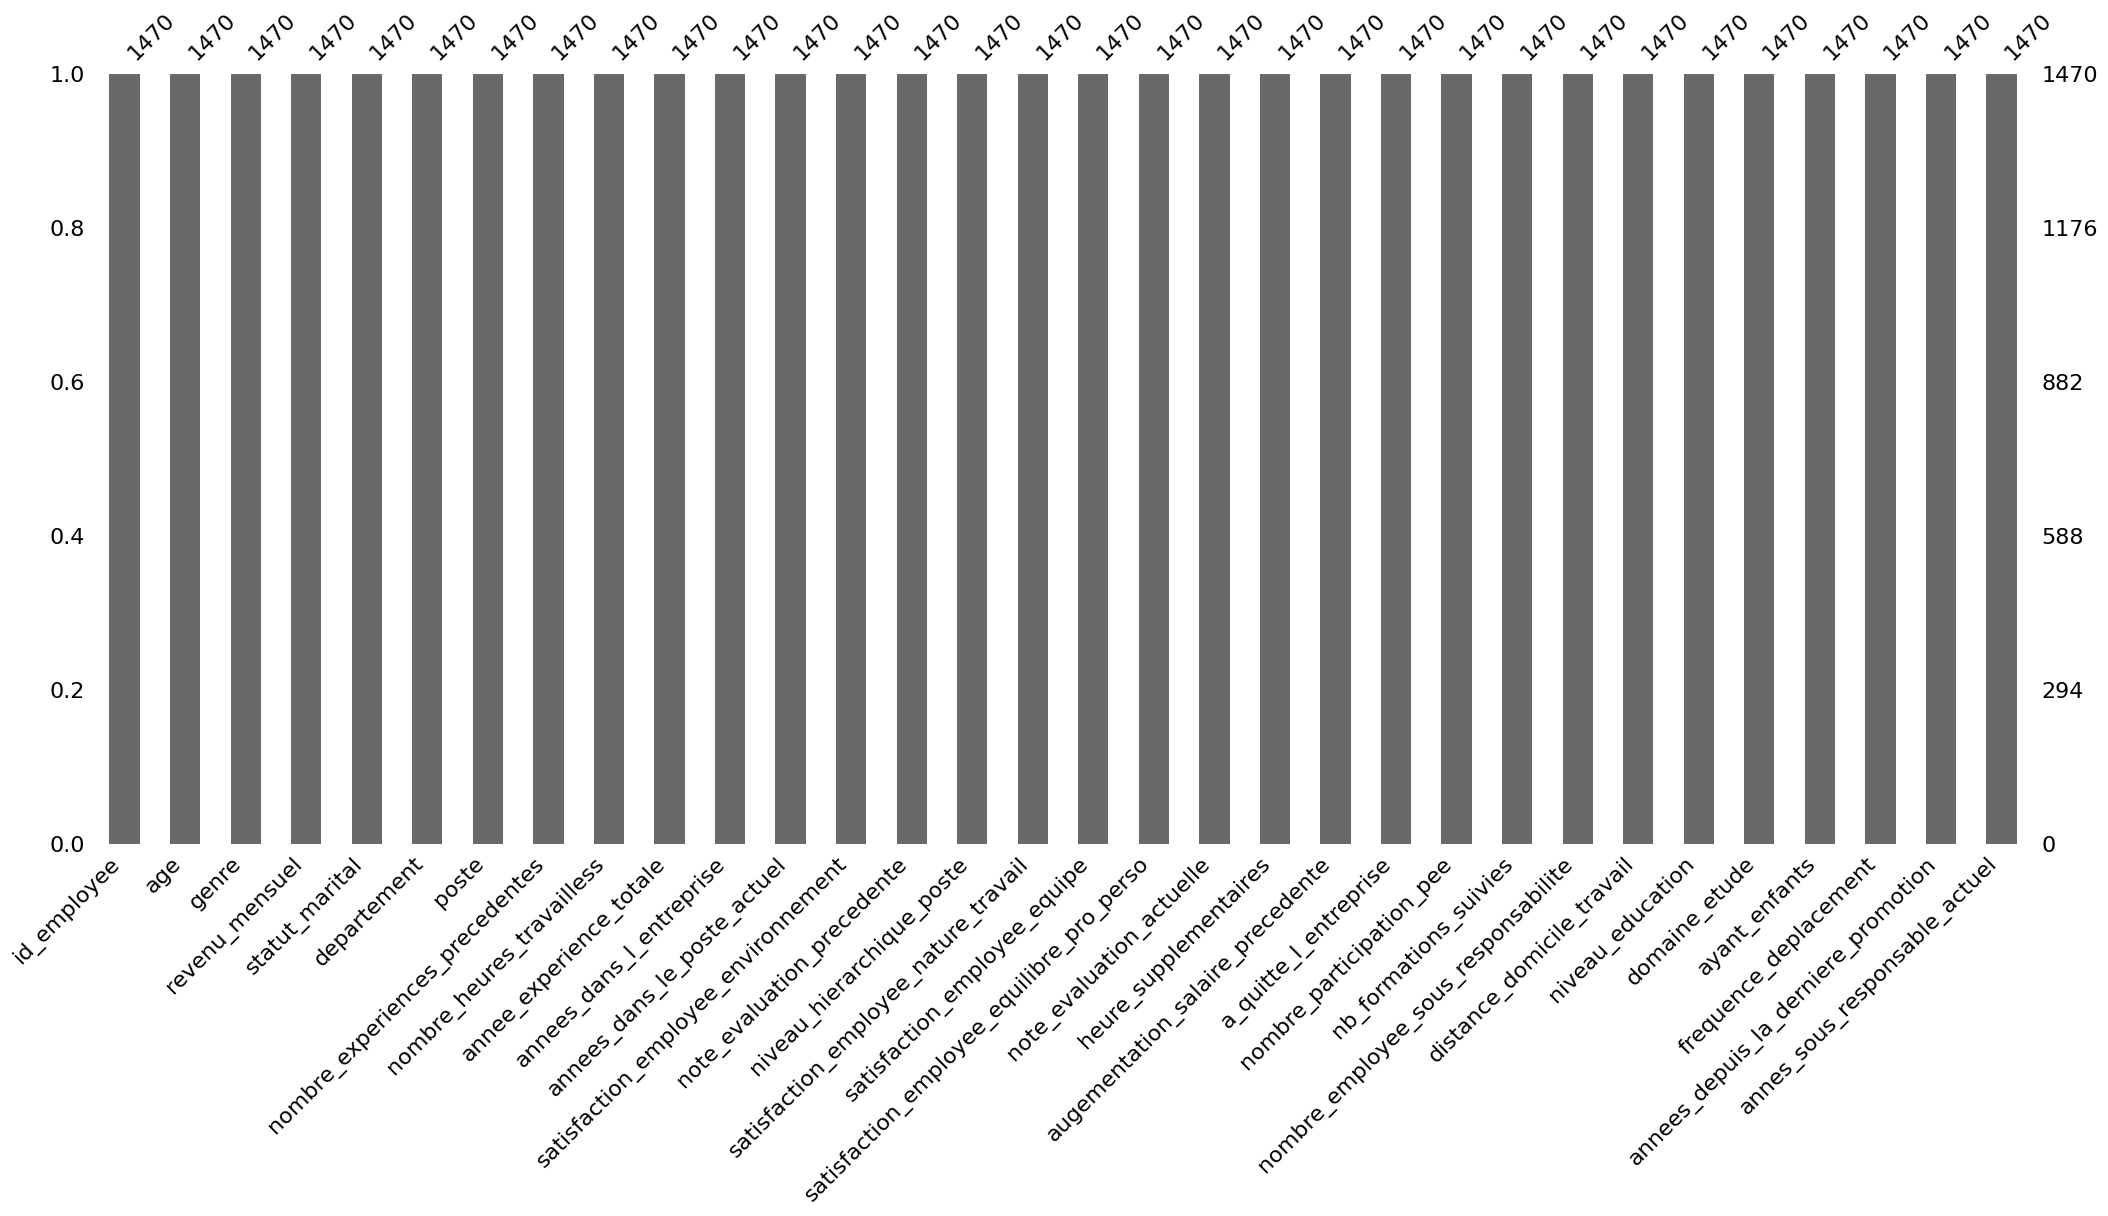

In [9]:
msno.bar(df_merge)

In [10]:
df_merge['a_quitte_l_entreprise'].value_counts()

a_quitte_l_entreprise
Non    1233
Oui     237
Name: count, dtype: int64

In [11]:
df_merge['departement'].value_counts()

departement
Consulting             961
Commercial             446
Ressources Humaines     63
Name: count, dtype: int64

In [12]:
df_merge['poste'].value_counts()

poste
Cadre Commercial           326
Assistant de Direction     292
Consultant                 259
Tech Lead                  145
Manager                    131
Senior Manager             102
Représentant Commercial     83
Directeur Technique         80
Ressources Humaines         52
Name: count, dtype: int64

In [13]:
df_merge['domaine_etude'].value_counts()

domaine_etude
Infra & Cloud              606
Transformation Digitale    464
Marketing                  159
Entrepreunariat            132
Autre                       82
Ressources Humaines         27
Name: count, dtype: int64

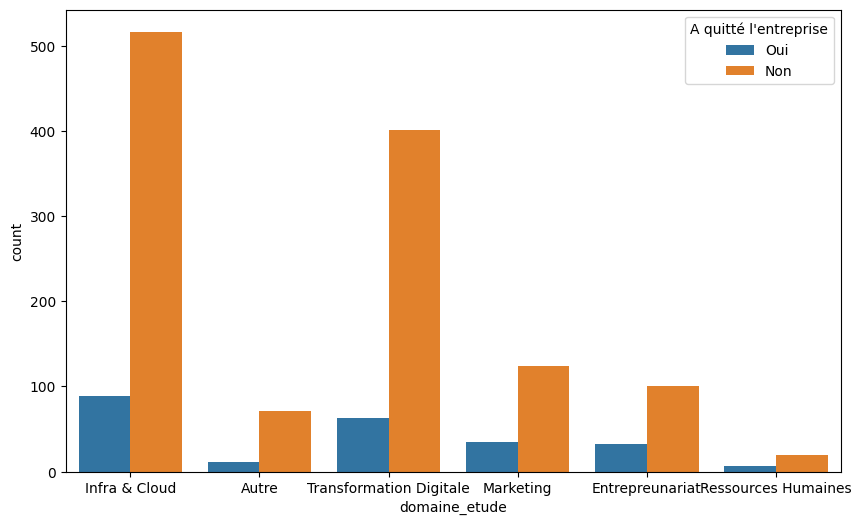

In [14]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='domaine_etude', hue='a_quitte_l_entreprise', data=df_merge)
ax.legend_.set_title("A quitté l'entreprise")

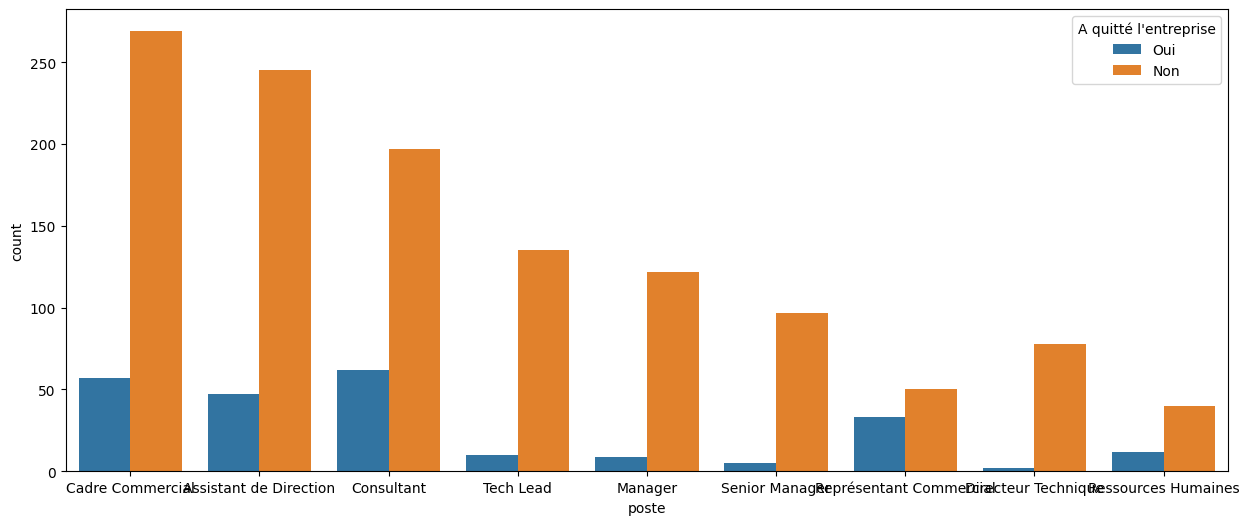

In [15]:
plt.figure(figsize=(15, 6))
ax = sns.countplot(x='poste', hue='a_quitte_l_entreprise', data=df_merge)
ax.legend_.set_title("A quitté l'entreprise")

### Feature Engineering

In [16]:
#remplacer les H et F du dataframe par 0 ou 1 
df_merge["genre"] = df_merge["genre"].map({'F': 0, 'M': 1})
df_merge["ayant_enfants"] = df_merge["ayant_enfants"].map({'Y': 0, 'N': 1})
df_merge["heure_supplementaires"] = df_merge["heure_supplementaires"].map({'Oui': 0, 'Non': 1})
df_merge["a_quitte_l_entreprise"] = df_merge["a_quitte_l_entreprise"].map({'Oui': 1, 'Non': 0})
df_merge.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,1,41,0,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,3,0,11 %,1,0,0,1,1,2,Infra & Cloud,0,Occasionnel,0,5
1,2,49,1,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,4,1,23 %,0,1,3,1,8,1,Infra & Cloud,0,Frequent,1,7
2,4,37,1,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,3,0,15 %,1,0,3,1,2,2,Autre,0,Occasionnel,0,0
3,5,33,0,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,3,0,11 %,0,0,3,1,3,4,Infra & Cloud,0,Frequent,3,0
4,7,27,1,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,3,1,12 %,0,1,3,1,2,1,Transformation Digitale,0,Occasionnel,2,2


In [17]:
df_merge["id_employee"] = df_merge["id_employee"].astype(int)

In [18]:
df_merge['augementation_salaire_precedente'] = df_merge['augementation_salaire_precedente'].str.rstrip('%').astype(float) / 100

In [19]:
df_merge['augementation_salaire_precedente'].value_counts()

augementation_salaire_precedente
0.11    210
0.13    209
0.14    201
0.12    198
0.15    101
0.18     89
0.17     82
0.16     78
0.19     76
0.22     56
0.20     55
0.21     48
0.23     28
0.24     21
0.25     18
Name: count, dtype: int64

In [20]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id_employee                                1470 non-null   int64  
 1   age                                        1470 non-null   int64  
 2   genre                                      1470 non-null   int64  
 3   revenu_mensuel                             1470 non-null   int64  
 4   statut_marital                             1470 non-null   object 
 5   departement                                1470 non-null   object 
 6   poste                                      1470 non-null   object 
 7   nombre_experiences_precedentes             1470 non-null   int64  
 8   nombre_heures_travailless                  1470 non-null   int64  
 9   annee_experience_totale                    1470 non-null   int64  
 10  annees_dans_l_entreprise

In [21]:
#colonne a encodé frequence_deplacement, domaine_etude, poste, departement, statut_marital
def encode_column_with_onehot(df, column_name, max_categories=100):
    # Initialiser le OneHotEncoder
    if column_name not in df.columns:
        print(f"La colonne '{column_name}' n'existe pas dans le DataFrame.")
        return df  # Retourner le DataFrame original sans modification
    encoder = OneHotEncoder(sparse_output=False, drop='first', max_categories=max_categories)  # drop='first' pour éviter la multicolinéarité
    # Appliquer l'encodage sur la colonne spécifiée
    encoded_array = encoder.fit_transform(df[[column_name]])
    # Récupérer les noms des colonnes encodées
    encoded_cols = encoder.get_feature_names_out([column_name])
    # Créer un DataFrame avec les colonnes encodées
    df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
    # Supprimer la colonne originale
    df = df.drop(columns=[column_name])
    # Concaténer le DataFrame original avec les colonnes encodées
    df_final = pd.concat([df, df_encoded], axis=1)
    return df_final



In [22]:
df = encode_column_with_onehot(df_merge, "frequence_deplacement")
df = encode_column_with_onehot(df, "domaine_etude")
df = encode_column_with_onehot(df, "poste")
df = encode_column_with_onehot(df, "departement")
df = encode_column_with_onehot(df, "statut_marital")

### Modélisation

In [27]:
# CODE PREPARATION DES FEATURES
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

X_building = df.drop('a_quitte_l_entreprise', axis=1)
y_building = df['a_quitte_l_entreprise']
X_train, X_test, y_train, y_test = train_test_split(X_building, y_building, test_size=0.2, random_state=42)

In [35]:
def modele_classification(df, target_col, modele_type):
    # Séparer les features et la cible
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # Diviser en train et test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Choisir le modèle
    if modele_type == 'logisticregression':
        model = LogisticRegression(max_iter=1000, class_weight='balanced')
    elif modele_type == 'dummyclassifier':
        model = DummyClassifier(strategy='most_frequent')
    elif modele_type == 'svc':
        model = SVC(probability=True, class_weight='balanced')
    elif modele_type == 'randomforestclassifier':
        model = RandomForestClassifier(random_state=42, class_weight='balanced')
    else:
        raise ValueError("Type de modèle non reconnu. Choisissez parmi : 'linearregression', 'dummyregressor', 'svr', 'randomforestregressor'.")
    
    # Entraîner le modèle
    model.fit(X_train, y_train)
    
    # Prédictions
    y_pred = model.predict(X_test)
    
    print(f"===== RÉSULTATS POUR : {modele_type} =====")
    
    # 2. Matrice de confusion (calcul)
    cm = confusion_matrix(y_test, y_pred)
    
    # 3. Matrice de confusion (Visualisation avec Seaborn)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                cbar=False, annot_kws={"size": 14})
    plt.title(f'Matrice de Confusion - {modele_type}')
    plt.ylabel('Vraie valeur (Actual)')
    plt.xlabel('Prédiction (Predicted)')
    plt.show()
    print("=" * (30 + len(modele_type)))
    
    # 2. Rapport de classification (inclut Précision, Rappel, F1-Score)
    print(f"\nRapport de Classification :")
    report = classification_report(y_test, y_pred)
    print(report)

    
    return y_test, y_pred

===== RÉSULTATS POUR : logisticregression =====


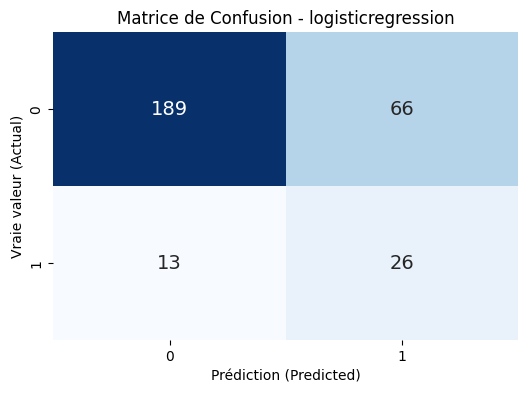


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.94      0.74      0.83       255
           1       0.28      0.67      0.40        39

    accuracy                           0.73       294
   macro avg       0.61      0.70      0.61       294
weighted avg       0.85      0.73      0.77       294



In [36]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'logisticregression')

===== RÉSULTATS POUR : randomforestclassifier =====


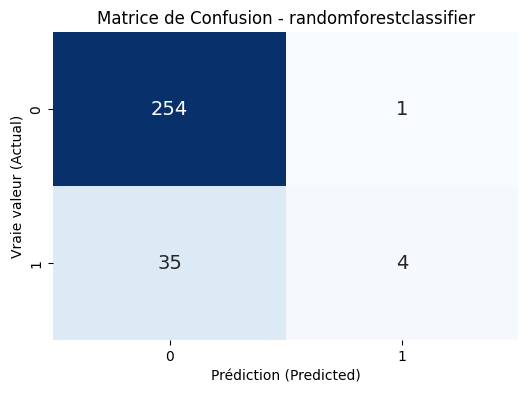


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



In [37]:
y_test_actual, y_pred_actual = modele_classification(df, 'a_quitte_l_entreprise', 'randomforestclassifier')